In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
BASE = Path("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline")
TRAIN_PATH = BASE / "data/datasets/sup_con_oof_embeddings.csv"
TEST_PATH = BASE / "data/datasets/temp/emb-dataset-sup-con-old-summaries.csv"
MIN_TEST_SAMPLES_PER_CLASS = 20  # filter test labels with at least this many samples

In [7]:
# Training set: supervised contrastive OOF embeddings (integer labels 0–7)
train_df = pd.read_csv(TRAIN_PATH)
# Test set: embeddings with string pattern labels
test_df = pd.read_csv(TEST_PATH)
print("Train shape:", train_df.shape, "| Test shape:", test_df.shape)

Train shape: (1980, 1540) | Test shape: (413, 1540)


In [3]:
# Embedding columns (common to both datasets)
emb_cols = [c for c in train_df.columns if c.startswith("emb_")]
assert len(emb_cols) == 1536, "Expected 1536 embedding dimensions"

# Build int <-> string label mapping from train/test overlap on 'file'
if "file" in train_df.columns and "file" in test_df.columns:
    merge = train_df[["file", "label"]].drop_duplicates().merge(
        test_df[["file", "label"]].drop_duplicates(), on="file", how="inner", suffixes=("_int", "_str")
    )
    int_to_str = merge.groupby("label_int")["label_str"].first().to_dict()
    str_to_int = {v: k for k, v in int_to_str.items()}
else:
    int_to_str = {}
    str_to_int = {}

# Restrict test to the 8 training classes and (optionally) to labels with enough samples
train_classes = set(train_df["label"].unique())
valid_str_labels = [s for s in str_to_int.keys() if str_to_int[s] in train_classes]
counts = test_df["label"].value_counts()
valid_str_labels = [l for l in valid_str_labels if counts.get(l, 0) >= MIN_TEST_SAMPLES_PER_CLASS]
test_df = test_df[test_df["label"].isin(valid_str_labels)].copy()
print("Label mapping (int -> str):", int_to_str)
print("Test samples after filter:", len(test_df), "| Classes:", sorted(test_df["label"].unique()))

Label mapping (int -> str): {0: 'Agent Architecture', 1: 'Forecasting with Classical Models', 2: 'LLM-based Multimodal Generative Prompting', 3: 'Model Abstraction', 4: 'Preprocessing Text and Numerical Data', 5: 'Retrieval Augmented Generation(RAG)', 6: 'Using Tools with LLMs', 7: 'none'}
Test samples after filter: 330 | Classes: ['Agent Architecture', 'Forecasting with Classical Models', 'LLM-based Multimodal Generative Prompting', 'Model Abstraction', 'Preprocessing Text and Numerical Data', 'Retrieval Augmented Generation(RAG)', 'Using Tools with LLMs', 'none']


In [4]:
# Feature matrices and labels
X_train = train_df[emb_cols].values
y_train = train_df["label"].values

# Encode test string labels to same integer space as train
y_test_str = test_df["label"].values
y_test = np.array([str_to_int[s] for s in y_test_str])
X_test = test_df[emb_cols].values

# Class names for reporting (use string labels for readability)
class_names = [int_to_str[i] for i in sorted(int_to_str.keys())]
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)
print("Classes:", class_names)

X_train: (1980, 1536) | y_train: (1980,)
X_test: (330, 1536) | y_test: (330,)
Classes: ['Agent Architecture', 'Forecasting with Classical Models', 'LLM-based Multimodal Generative Prompting', 'Model Abstraction', 'Preprocessing Text and Numerical Data', 'Retrieval Augmented Generation(RAG)', 'Using Tools with LLMs', 'none']


In [5]:
# Scale features (fit on train, transform both) — required for SVC, LogReg, KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Define classifiers (pipelines with built-in scaling for fair comparison)
models = {
    "LogReg": make_pipeline(
        StandardScaler(),
        LogisticRegression(C=10, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    ),
    "SVC": make_pipeline(
        StandardScaler(),
        SVC(C=10, kernel="rbf", class_weight="balanced", probability=True, gamma="scale", random_state=RANDOM_STATE),
    ),
    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=15, metric="cosine"),
    ),
}

# Train on full training set and evaluate on test set
results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)  # pipeline fits scaler + estimator
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1w = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    results[name] = {"accuracy": acc, "f1_weighted": f1w, "predictions": y_pred, "model": clf}
    print(f"{name}: accuracy={acc:.4f}, F1_weighted={f1w:.4f}")

LogReg: accuracy=0.8758, F1_weighted=0.8751
SVC: accuracy=0.9303, F1_weighted=0.9299
KNN: accuracy=0.8788, F1_weighted=0.8781


In [7]:
# Best model by weighted F1
best_name = max(results, key=lambda k: results[k]["f1_weighted"])
best_pred = results[best_name]["predictions"]
print(f"Best model: {best_name} (F1_weighted = {results[best_name]['f1_weighted']:.4f})")

Best model: SVC (F1_weighted = 0.9299)


In [8]:
# Classification report for best model
print("Classification report (best model =", best_name, "):\n")
print(classification_report(y_test, best_pred, target_names=class_names, zero_division=0))

Classification report (best model = SVC ):

                                           precision    recall  f1-score   support

                       Agent Architecture       0.89      0.80      0.84        20
        Forecasting with Classical Models       0.98      0.98      0.98        64
LLM-based Multimodal Generative Prompting       0.95      1.00      0.97        52
                        Model Abstraction       1.00      0.85      0.92        20
    Preprocessing Text and Numerical Data       0.98      0.92      0.95        51
      Retrieval Augmented Generation(RAG)       1.00      0.79      0.88        28
                    Using Tools with LLMs       0.85      0.90      0.88        31
                                     none       0.85      0.97      0.91        64

                                 accuracy                           0.93       330
                                macro avg       0.94      0.90      0.92       330
                             weighted avg

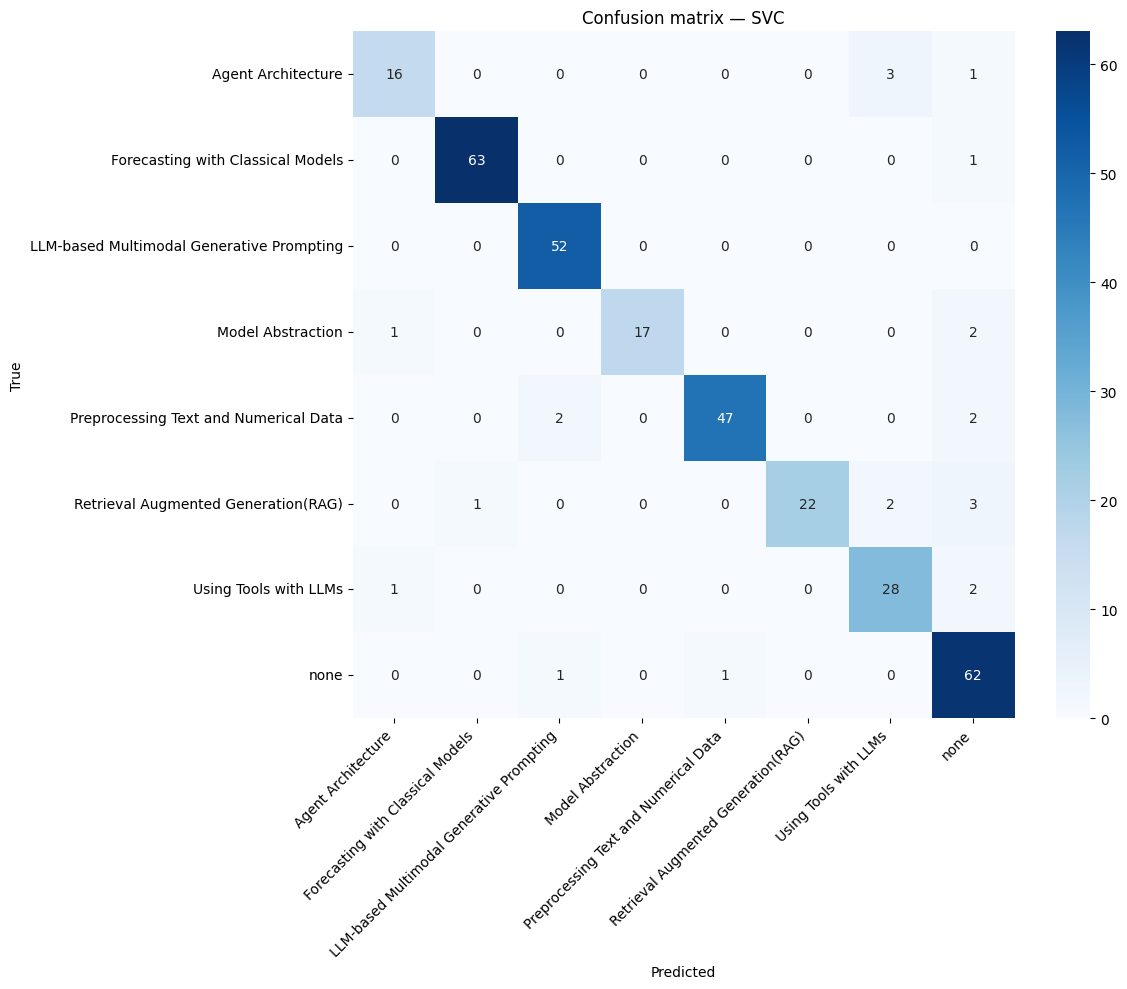

In [9]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — {best_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 5-fold classification on test set (OOF evaluation)

This section uses **only** the test dataset (`TEST_PATH`). We run 5-fold stratified cross-validation and evaluate using **out-of-fold (OOF)** predictions: each sample is predicted by a model trained on the other 4 folds.

In [3]:
# Load test dataset only
df_test = pd.read_csv(TEST_PATH)
emb_cols_test = [c for c in df_test.columns if c.startswith("emb_")]

# Filter to classes with enough samples for 5-fold stratified CV (at least 5 per class)
counts = df_test["label"].value_counts()
valid_labels = counts[counts >= 20].index
df_test = df_test[df_test["label"].isin(valid_labels)].copy()

# Encode string labels to integers
le_oof = LabelEncoder()
y_oof = le_oof.fit_transform(df_test["label"].values)
X_oof = df_test[emb_cols_test].values
class_names_oof = le_oof.classes_.tolist()

print("Test-only dataset: n_samples =", len(X_oof), "| n_classes =", len(class_names_oof))
print("Classes:", class_names_oof)

Test-only dataset: n_samples = 330 | n_classes = 8
Classes: ['Agent Architecture', 'Forecasting with Classical Models', 'LLM-based Multimodal Generative Prompting', 'Model Abstraction', 'Preprocessing Text and Numerical Data', 'Retrieval Augmented Generation(RAG)', 'Using Tools with LLMs', 'none']


In [4]:
# 5-fold stratified CV: collect OOF predictions for each model
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

models_oof = {
    "LogReg": make_pipeline(
        StandardScaler(),
        LogisticRegression(C=10, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    ),
    "SVC": make_pipeline(
        StandardScaler(),
        SVC(C=10, kernel="rbf", class_weight="balanced", probability=True, gamma="scale", random_state=RANDOM_STATE),
    ),
    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=15, metric="cosine"),
    ),
}

oof_preds = {name: np.empty(len(y_oof), dtype=int) for name in models_oof}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_oof, y_oof)):
    X_tr, X_val = X_oof[train_idx], X_oof[val_idx]
    y_tr = y_oof[train_idx]
    for name, clf in models_oof.items():
        clf.fit(X_tr, y_tr)
        oof_preds[name][val_idx] = clf.predict(X_val)
    print(f"Fold {fold + 1}/{N_FOLDS} done.")

Fold 1/5 done.
Fold 2/5 done.
Fold 3/5 done.
Fold 4/5 done.
Fold 5/5 done.


In [5]:
# OOF evaluation: compare models and show best
results_oof = {}
for name in models_oof:
    acc = accuracy_score(y_oof, oof_preds[name])
    f1w = f1_score(y_oof, oof_preds[name], average="weighted", zero_division=0)
    results_oof[name] = {"accuracy": acc, "f1_weighted": f1w}
    print(f"{name}: OOF accuracy = {acc:.4f}, OOF F1_weighted = {f1w:.4f}")

best_name_oof = max(results_oof, key=lambda k: results_oof[k]["f1_weighted"])
print(f"\nBest model (OOF): {best_name_oof}")

LogReg: OOF accuracy = 0.5636, OOF F1_weighted = 0.5611
SVC: OOF accuracy = 0.5364, OOF F1_weighted = 0.5249
KNN: OOF accuracy = 0.5121, OOF F1_weighted = 0.5059

Best model (OOF): LogReg


In [6]:
# Classification report (OOF) for best model
print("Classification report (OOF — best model =", best_name_oof, "):\n")
print(classification_report(y_oof, oof_preds[best_name_oof], target_names=class_names_oof, zero_division=0))

Classification report (OOF — best model = LogReg ):

                                           precision    recall  f1-score   support

                       Agent Architecture       0.50      0.70      0.58        20
        Forecasting with Classical Models       0.66      0.67      0.67        64
LLM-based Multimodal Generative Prompting       0.60      0.62      0.61        52
                        Model Abstraction       0.69      0.55      0.61        20
    Preprocessing Text and Numerical Data       0.52      0.53      0.52        51
      Retrieval Augmented Generation(RAG)       0.63      0.61      0.62        28
                    Using Tools with LLMs       0.56      0.61      0.58        31
                                     none       0.42      0.36      0.39        64

                                 accuracy                           0.56       330
                                macro avg       0.57      0.58      0.57       330
                             wei

In [ ]:
# Confusion matrix (OOF) for best model
cm_oof = confusion_matrix(y_oof, oof_preds[best_name_oof])
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_oof, annot=True, fmt="d", cmap="Blues", xticklabels=class_names_oof, yticklabels=class_names_oof, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (OOF) — {best_name_oof}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 5-fold classification on train set (OOF, file-level split)

This section runs **5-fold stratified CV on the train dataset** (`TRAIN_PATH`) and evaluates using out-of-fold (OOF) predictions, in the same way as the test-set section above.

**Important constraint:** In this dataset, each `file` value appears in **6 rows** (same file, same label, repeated). To avoid data leakage, **all rows that share the same `file` must stay in a single fold** — we never train on some rows of a file and validate on other rows of the same file. So the split is done at the **file level**: we assign each unique file to one fold, then assign every row to that file’s fold.

In [9]:
# Load train dataset and prepare file-level split
df_train = pd.read_csv(TRAIN_PATH)
emb_cols_train = [c for c in df_train.columns if c.startswith("emb_")]

# One label per file (all 6 rows of a file have the same label)
file_to_label = df_train.groupby("file")["label"].first()
files_ordered = file_to_label.index.tolist()
y_files = file_to_label.values  # label for each unique file

# Assign each file to a fold (stratified by label); same file → same fold
N_FOLDS_TRAIN = 5
skf_files = StratifiedKFold(n_splits=N_FOLDS_TRAIN, shuffle=True, random_state=RANDOM_STATE)
file_to_fold = np.empty(len(files_ordered), dtype=int)
for fold, (_, val_fi) in enumerate(skf_files.split(np.arange(len(files_ordered)), y_files)):
    file_to_fold[val_fi] = fold

file_to_idx = {f: i for i, f in enumerate(files_ordered)}
# For each row, get its fold from its file
row_fold = np.array([file_to_fold[file_to_idx[f]] for f in df_train["file"]])

X_train_oof = df_train[emb_cols_train].values
y_train_oof = df_train["label"].values
class_names_train = sorted(df_train["label"].unique().tolist())

print("Train dataset: n_rows =", len(X_train_oof), "| n_unique_files =", len(files_ordered), "| rows per file = 6")
print("Folds (file-level):", np.bincount(file_to_fold))

Train dataset: n_rows = 1980 | n_unique_files = 330 | rows per file = 6
Folds (file-level): [66 66 66 66 66]


In [10]:
# 5-fold CV: train on 4 folds of files, predict on the held-out fold (OOF)
models_train_oof = {
    "LogReg": make_pipeline(
        StandardScaler(),
        LogisticRegression(C=10, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    ),
    "SVC": make_pipeline(
        StandardScaler(),
        SVC(C=10, kernel="rbf", class_weight="balanced", probability=True, gamma="scale", random_state=RANDOM_STATE),
    ),
    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=15, metric="cosine"),
    ),
}

oof_preds_train = {name: np.empty(len(y_train_oof), dtype=int) for name in models_train_oof}

for fold in range(N_FOLDS_TRAIN):
    train_mask = row_fold != fold
    val_mask = row_fold == fold
    X_tr = X_train_oof[train_mask]
    y_tr = y_train_oof[train_mask]
    X_val = X_train_oof[val_mask]
    for name, clf in models_train_oof.items():
        clf.fit(X_tr, y_tr)
        oof_preds_train[name][val_mask] = clf.predict(X_val)
    print(f"Fold {fold + 1}/{N_FOLDS_TRAIN} done.")

Fold 1/5 done.
Fold 2/5 done.
Fold 3/5 done.
Fold 4/5 done.
Fold 5/5 done.


In [11]:
# OOF evaluation on train: compare models and pick best
results_train_oof = {}
for name in models_train_oof:
    acc = accuracy_score(y_train_oof, oof_preds_train[name])
    f1w = f1_score(y_train_oof, oof_preds_train[name], average="weighted", zero_division=0)
    results_train_oof[name] = {"accuracy": acc, "f1_weighted": f1w}
    print(f"{name}: OOF accuracy = {acc:.4f}, OOF F1_weighted = {f1w:.4f}")

best_name_train_oof = max(results_train_oof, key=lambda k: results_train_oof[k]["f1_weighted"])
print(f"\nBest model (train OOF): {best_name_train_oof}")

LogReg: OOF accuracy = 0.5207, OOF F1_weighted = 0.5190
SVC: OOF accuracy = 0.5702, OOF F1_weighted = 0.5734
KNN: OOF accuracy = 0.5313, OOF F1_weighted = 0.5178

Best model (train OOF): SVC


In [12]:
# Classification report (train OOF) for best model
print("Classification report (train OOF — best model =", best_name_train_oof, "):\n")
print(classification_report(y_train_oof, oof_preds_train[best_name_train_oof], target_names=[str(c) for c in class_names_train], zero_division=0))

Classification report (train OOF — best model = SVC ):

              precision    recall  f1-score   support

           0       0.55      0.40      0.46       120
           1       0.70      0.72      0.71       384
           2       0.66      0.63      0.65       312
           3       0.77      0.45      0.57       120
           4       0.52      0.47      0.49       306
           5       0.75      0.53      0.62       168
           6       0.57      0.51      0.54       186
           7       0.40      0.59      0.48       384

    accuracy                           0.57      1980
   macro avg       0.61      0.54      0.56      1980
weighted avg       0.59      0.57      0.57      1980



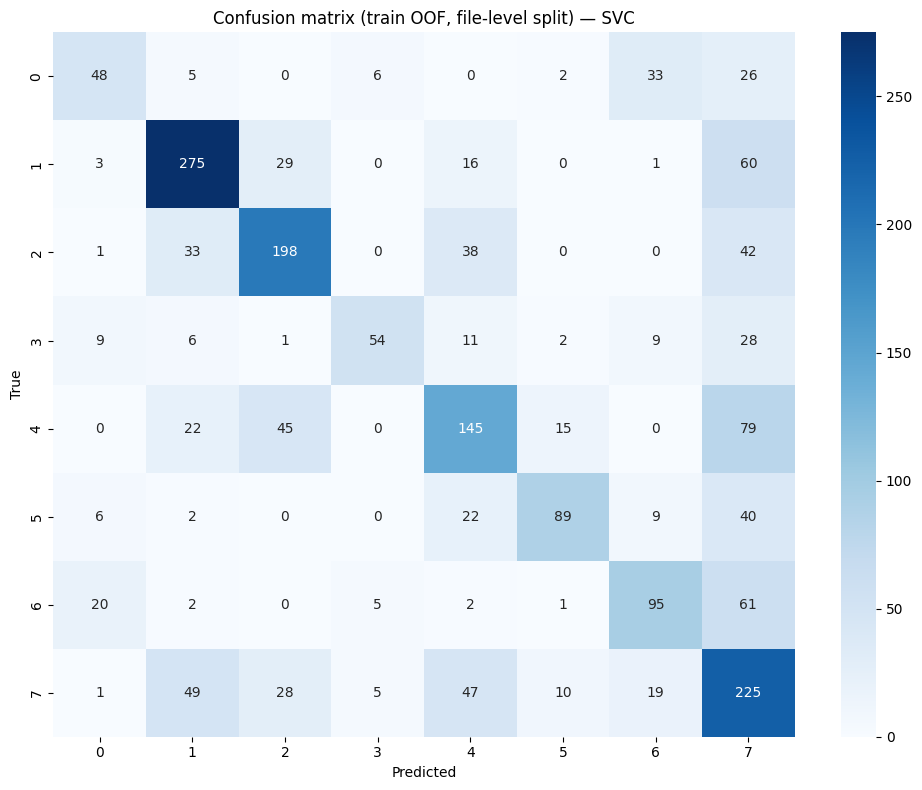

In [13]:
# Confusion matrix (train OOF) for best model
cm_train_oof = confusion_matrix(y_train_oof, oof_preds_train[best_name_train_oof])
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_train_oof, annot=True, fmt="d", cmap="Blues", xticklabels=class_names_train, yticklabels=class_names_train, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (train OOF, file-level split) — {best_name_train_oof}")
plt.tight_layout()
plt.show()

In [8]:
train_df

,fold,label,file,description,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_1526,emb_1527,emb_1528,emb_1529,emb_1530,emb_1531,emb_1532,emb_1533,emb_1534,emb_1535
0,1,2,https://github.com/HasinthakaPiyumal/AI-Patter...,This code implements data preprocessing patter...,0.002457,0.037354,0.025513,-0.028198,0.029541,0.026611,...,0.038330,0.025269,0.042480,-0.001320,0.017578,0.060791,0.016968,-0.001160,0.000196,0.022949
1,1,2,https://github.com/HasinthakaPiyumal/AI-Patter...,This code demonstrates AI patterns for 3D obje...,0.029785,0.011108,-0.010620,-0.004791,-0.008301,0.049072,...,0.031982,0.007416,0.017700,-0.021973,0.000858,0.027588,0.011780,-0.000751,0.008789,0.027100
2,1,2,https://github.com/HasinthakaPiyumal/AI-Patter...,This code implements data loading and preproce...,-0.009888,0.058105,0.006561,-0.025757,0.062256,0.047852,...,0.032959,0.012024,0.020752,0.037109,0.006622,0.015625,0.014526,-0.020264,0.027100,0.030029
3,1,0,https://github.com/HasinthakaPiyumal/AI-Patter...,This code demonstrates a multi-agent orchestra...,0.014832,0.013245,-0.001442,-0.011963,0.036133,0.037354,...,0.038574,-0.027100,0.054199,-0.011902,0.009766,0.024292,-0.004517,-0.001091,0.021362,-0.012512
4,1,7,https://github.com/HasinthakaPiyumal/AI-Patter...,This code implements a robust distributed Remo...,0.042969,0.043457,-0.012512,-0.012268,0.016479,0.055664,...,0.064453,0.001915,0.044434,0.011597,0.024536,0.045410,-0.007416,0.012573,-0.007538,-0.010925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975,5,5,https://github.com/HasinthakaPiyumal/AI-Patter...,Adapter/wrapper pattern: AurelioSparseEncoder ...,-0.011047,-0.030151,0.002075,-0.028687,0.023193,0.046875,...,0.022095,-0.005768,0.064941,0.003021,-0.024902,0.025513,0.002426,0.017456,0.008240,0.024780
1976,5,4,https://github.com/HasinthakaPiyumal/AI-Patter...,A CTGAN-based conditional tabular data synthes...,0.003723,-0.016357,0.005951,-0.011536,0.014038,0.048340,...,0.000900,-0.028931,0.043945,-0.015259,-0.043701,0.033936,-0.039307,-0.002029,0.034912,0.020142
1977,5,4,https://github.com/HasinthakaPiyumal/AI-Patter...,The code showcases recursive tree processing t...,-0.002029,0.018311,0.026611,-0.010681,0.006165,0.052246,...,0.019409,0.009094,0.052734,0.028687,0.002274,0.009766,-0.027832,0.014465,0.001045,-0.001549
1978,5,0,https://github.com/HasinthakaPiyumal/AI-Patter...,The code illustrates a multi-agent orchestrati...,-0.003677,0.062988,-0.005798,-0.001549,0.026489,0.019287,...,-0.008850,-0.016602,0.012268,0.020630,-0.016602,0.015747,-0.008240,0.000652,0.014771,0.013367
